Verifying raw data shapes: (786432,)
Real cosmic shear value scale check: Min=-0.0107, Max=0.0164
Projecting HEALPix sphere to flat maps...
Processing Aperture Mass Map...


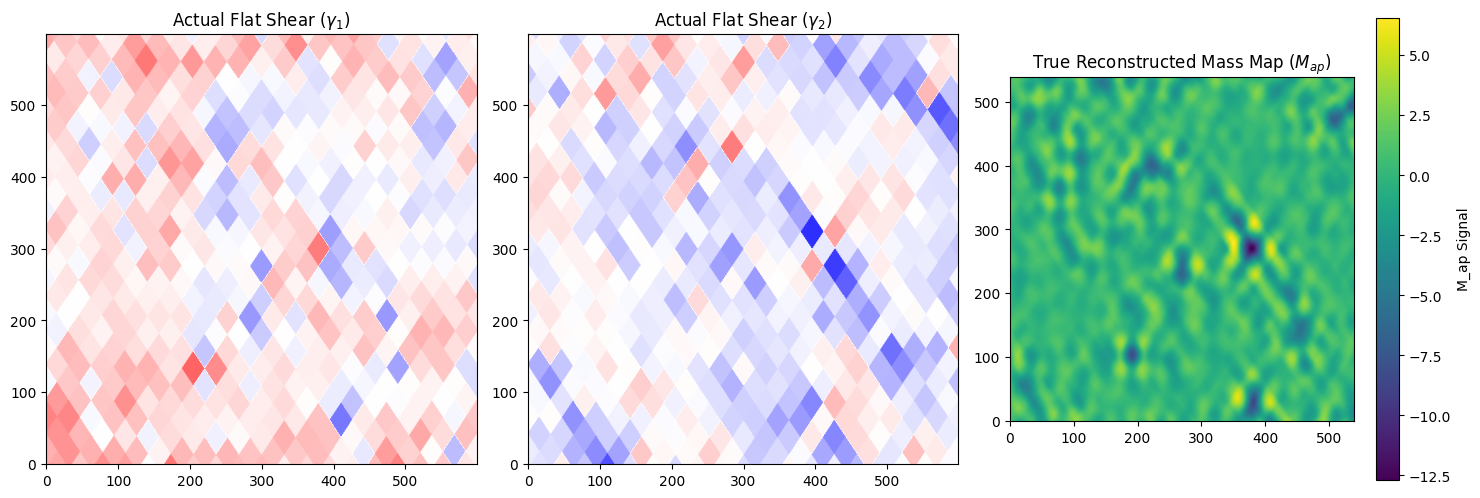

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

# 1. Load data explicitly to clear old memory
g1_raw = np.load("gamma1.npy")
g2_raw = np.load("gamma2.npy")

print(f"Verifying raw data shapes: {g1_raw.shape}")
print(f"Real cosmic shear value scale check: Min={g1_raw.min():.4f}, Max={g1_raw.max():.4f}")

# Supervisor's setup
ra0, dec0 = 45, 45
mapsize = 5 
res_arcmin = 0.5 
Npix = int(mapsize * 60 / res_arcmin)

# Explicit projection step
print("Projecting HEALPix sphere to flat maps...")
plt.figure(figsize=(1,1))
g1_flat = hp.gnomview(g1_raw, rot=[ra0, dec0], xsize=Npix, reso=res_arcmin, return_projected_map=True)
g2_flat = hp.gnomview(g2_raw, rot=[ra0, dec0], xsize=Npix, reso=res_arcmin, return_projected_map=True)
plt.close('all')

# Schirmer kernel setup (Hetterscheidt et al. 2005)
def schirmer_kernel(x):
    a, b, c, d, x_c = 6.0, 150.0, 50.0, 0.75, 0.1
    x = np.where(x == 0, 1e-5, x)
    return (x / x_c) * (1.0 / (1.0 + np.exp(a - b*x) + np.exp(c*(x - d))))

R_pix = 30 
Map_matrix = np.zeros((Npix, Npix))

y_idx, x_idx = np.indices((2 * R_pix + 1, 2 * R_pix + 1))
dy, dx = y_idx - R_pix, x_idx - R_pix
r_distances = np.sqrt(dx**2 + dy**2)
normalized_r = r_distances / R_pix
phi = np.arctan2(dy, dx)
cos_2phi, sin_2phi = np.cos(2 * phi), np.sin(2 * phi)

aperture_mask = r_distances <= R_pix
kernel_weights = schirmer_kernel(normalized_r) * aperture_mask

print("Processing Aperture Mass Map...")
for y in range(R_pix, Npix - R_pix):
    for x in range(R_pix, Npix - R_pix):
        g1_sub = g1_flat[y - R_pix : y + R_pix + 1, x - R_pix : x + R_pix + 1]
        g2_sub = g2_flat[y - R_pix : y + R_pix + 1, x - R_pix : x + R_pix + 1]
        gamma_t = -g1_sub * cos_2phi - g2_sub * sin_2phi
        Map_matrix[y, x] = np.sum(gamma_t * kernel_weights)

# Plotting with proper divergent color scaling for weak lensing
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(g1_flat, cmap='bwr', origin='lower', vmin=-0.005, vmax=0.005)
ax[0].set_title("Actual Flat Shear ($\gamma_1$)")

ax[1].imshow(g2_flat, cmap='bwr', origin='lower', vmin=-0.005, vmax=0.005)
ax[1].set_title("Actual Flat Shear ($\gamma_2$)")

cropped_map = Map_matrix[R_pix : Npix - R_pix, R_pix : Npix - R_pix]
im = ax[2].imshow(cropped_map, cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[2], label='M_ap Signal')
ax[2].set_title("True Reconstructed Mass Map ($M_{ap}$)")

plt.tight_layout()
plt.show()